# Day 4 | Lab 4.2: Embeddings & Vector Stores — FAISS · ChromaDB · Titan v2

**Duration:** ~1.5 hours

**Scenario.** Mixed-domain semantic search examples — banking products, insurance claims, healthcare FAQ — preserved from the GM source notebooks. Foundational concepts apply identically to financial services use cases (compliance KB, policy doc retrieval, RM playbooks).

**Learning Objectives.** By the end of this lab, you will be able to:
1. Generate text embeddings with OpenAI (`text-embedding-3-small/large`) and AWS Bedrock (Titan Embed v2).
2. Compare embedding models on the same task — small vs large vs open-source vs cloud-native.
3. Use the right similarity metric — cosine vs euclidean vs dot product — and know when each agrees.
4. Build a FAISS in-memory index for fast in-process search; persist with `save_local` / `load_local`.
5. Build a ChromaDB persistent vector store, add documents with metadata, and run filtered queries.
6. Visualise embedding space (2D t-SNE) and read the cluster structure.
7. Choose between Flat (exact) / IVF / HNSW indexes for different scale + latency budgets.

**Tools.** OpenAI `text-embedding-3-small` · AWS Bedrock `amazon.titan-embed-text-v2:0` · FAISS · ChromaDB · scikit-learn · matplotlib.

*Merged from GM Module 4 Labs 1 & 2 (Embeddings + Mini Semantic Search Engine). Created by Prashant Sahu · [LinkedIn](https://www.linkedin.com/in/prashantksahu/)*

---


## 1. API Key Configuration

In [ ]:
import os

# Local-venv pattern: load from .env if python-dotenv is available, otherwise rely on
# environment variables already set in your shell or venv activation script.
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

for key in ['OPENAI_API_KEY', 'AWS_ACCESS_KEY_ID', 'AWS_SECRET_ACCESS_KEY', 'AWS_DEFAULT_REGION']:
    status = '✅ Loaded' if os.environ.get(key) else '❌ MISSING'
    print(f'{key}: {status}')


## 2. Imports & Helper Functions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE

# Initialize OpenAI client
openai_client = OpenAI()

print("Client initialized ✅")

Client initialized ✅


In [ ]:
def get_openai_embeddings(texts, model="text-embedding-3-small"):
    """
    Generate embeddings for a list of texts using OpenAI's Embeddings API.
    Supports batching — send up to 2048 texts in one call.

    Args:
        texts: list of strings to embed
        model: 'text-embedding-3-small' (1536d) or 'text-embedding-3-large' (3072d)

    Returns: numpy array of shape (len(texts), embedding_dim)
    """
    response = openai_client.embeddings.create(
        model=model,
        input=texts
    )
    # Extract embedding vectors in the correct order
    embeddings = [item.embedding for item in response.data]
    return np.array(embeddings)


def compute_similarity_matrix(embeddings):
    """Compute pairwise cosine similarity matrix for a set of embeddings."""
    return cosine_similarity(embeddings)


def show_similarity_heatmap(texts, sim_matrix, title="Cosine Similarity"):
    """Display a heatmap of pairwise cosine similarities."""
    # Truncate long text labels for display
    labels = [t[:50] + "..." if len(t) > 50 else t for t in texts]

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

    # Annotate cells with similarity scores
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{sim_matrix[i][j]:.2f}",
                    ha='center', va='center', fontsize=7,
                    color='white' if sim_matrix[i][j] > 0.7 else 'black')

    plt.colorbar(im, ax=ax, label='Cosine Similarity')
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

print("Helper functions defined ✅")

Helper functions defined ✅


---

## 4. Task 1 — Understanding Embeddings: Banking Product Descriptions

### Business Scenario
A retail bank wants to build a **product recommendation engine**. When a customer describes what they need (e.g., "I want to save for retirement"), the system should match them to the most relevant banking product.

We start by embedding product descriptions and computing how similar they are to each other — and to customer queries.

In [ ]:
# Banking product descriptions
products = [
    "High-yield savings account with 4.5% APY, no minimum balance, FDIC insured up to $250,000",
    "Fixed deposit account with guaranteed returns, lock-in periods of 6 to 60 months",
    "Retirement pension plan with tax benefits, employer matching, and diversified fund options",
    "Personal home loan at competitive interest rates with flexible EMI options up to 30 years",
    "Business line of credit for working capital needs, revolving facility up to $500,000",
    "Student education loan covering tuition, living expenses, with grace period after graduation",
    "Credit card with cashback rewards on dining, travel, and online shopping",
    "Travel insurance covering medical emergencies, trip cancellation, and lost baggage abroad",
]

# Generate embeddings
print("Generating embeddings for 8 banking products...")
product_embeddings = get_openai_embeddings(products, model="text-embedding-3-small")

print(f"Embedding shape: {product_embeddings.shape}")
print(f"Each product → vector of {product_embeddings.shape[1]} dimensions")

Generating embeddings for 8 banking products...
Embedding shape: (8, 1536)
Each product → vector of 1536 dimensions


In [22]:
product_embeddings[0][:10]  # look into the 1st 10 numbers of the 1st document embedding

array([-0.00509109,  0.01859551, -0.01280142,  0.09125404, -0.00791443,
        0.0078634 , -0.01169022,  0.053292  ,  0.0268501 , -0.04047924])

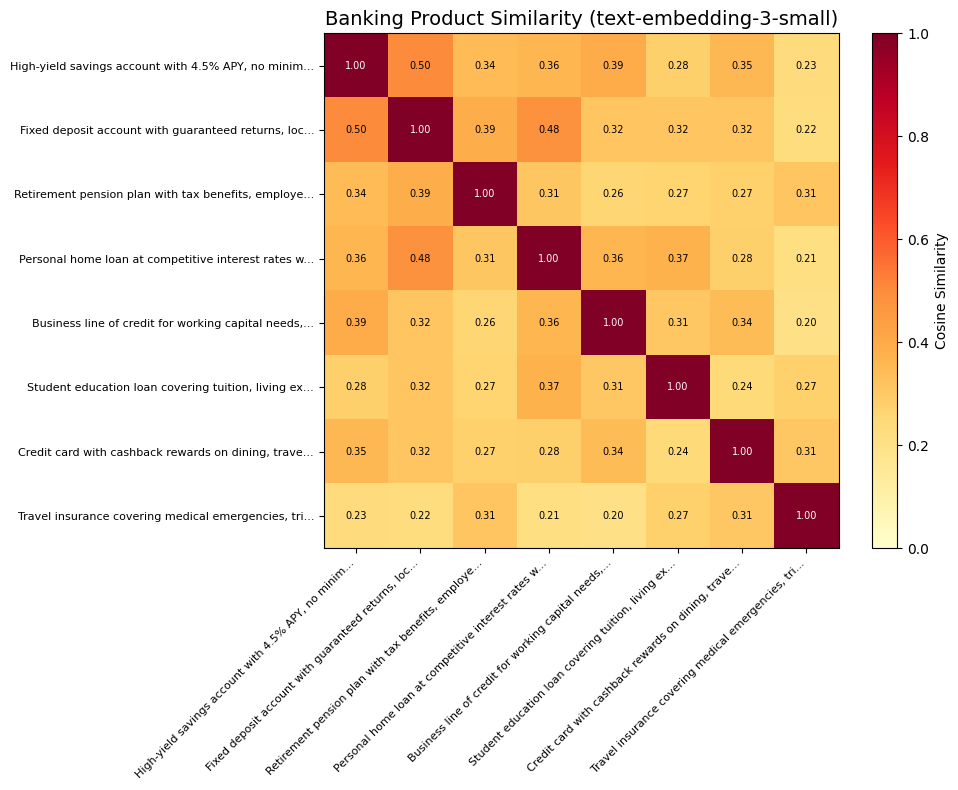

In [ ]:
# Compute and display the pairwise similarity matrix
sim_matrix = compute_similarity_matrix(product_embeddings)
show_similarity_heatmap(products, sim_matrix, title="Banking Product Similarity (text-embedding-3-small)")

**Interpretation guide:**
- Scores close to **1.0** = very similar (diagonal is always 1.0 — a text vs itself)
- Scores around **0.7–0.85** = related concepts (e.g., savings account vs fixed deposit)
- Scores around **0.3–0.5** = loosely related (both are financial products but different categories)
- Scores below **0.3** = semantically distant

In [ ]:
# Now test with customer queries — find the best matching product
customer_queries = [
    "I want to grow my money safely with good interest",
    "I need money to buy my first house",
    "My daughter is going to college next year and needs financial help",
    "I'm planning a trip to Europe and want protection against emergencies",
    "I want to save for my retirement with tax advantages",
]

query_embeddings = get_openai_embeddings(customer_queries)

# Compute similarity between each query and all products
query_product_sim = cosine_similarity(query_embeddings, product_embeddings)

# Show best match for each query
print("🏦 Customer Query → Best Matching Product\n")
for i, query in enumerate(customer_queries):
    best_idx = np.argmax(query_product_sim[i])
    score = query_product_sim[i][best_idx]
    print(f"Query: \"{query}\"")
    print(f"  → Match: {products[best_idx]}")
    print(f"  → Score: {score:.4f}\n")

🏦 Customer Query → Best Matching Product

Query: "I want to grow my money safely with good interest"
  → Match: Fixed deposit account with guaranteed returns, lock-in periods of 6 to 60 months
  → Score: 0.4480

Query: "I need money to buy my first house"
  → Match: Personal home loan at competitive interest rates with flexible EMI options up to 30 years
  → Score: 0.3185

Query: "My daughter is going to college next year and needs financial help"
  → Match: Student education loan covering tuition, living expenses, with grace period after graduation
  → Score: 0.3955

Query: "I'm planning a trip to Europe and want protection against emergencies"
  → Match: Travel insurance covering medical emergencies, trip cancellation, and lost baggage abroad
  → Score: 0.5974

Query: "I want to save for my retirement with tax advantages"
  → Match: Retirement pension plan with tax benefits, employer matching, and diversified fund options
  → Score: 0.5980



### 💡 Key Takeaway
Notice how embeddings capture **semantic meaning**, not just keyword overlap. "I want to grow my money safely" matches the savings account even though the words don't overlap much. This is the power of embeddings over traditional keyword search.

---

## 5. Task 2 — Embedding Model Comparison: Small vs Large

### Business Scenario
An insurance company is building a **claims categorization system**. They need to decide which embedding model to use — the smaller, cheaper model or the larger, more accurate one. We compare both on nuanced insurance text.

In [ ]:
# Insurance claim descriptions — some are subtly different
claims = [
    "Patient underwent cardiac bypass surgery after acute myocardial infarction",
    "Emergency heart surgery performed following a severe heart attack",
    "Routine annual health checkup with blood work and ECG",
    "Vehicle rear-ended at traffic signal, driver sustained whiplash injury",
    "Car accident at intersection caused neck and back injuries to driver",
    "Water damage to basement due to pipe burst during winter freeze",
    "Frozen pipes caused flooding in ground floor of insured property",
    "Laptop stolen from hotel room during business trip",
]

# Generate embeddings with both models
print("Generating with text-embedding-3-small (1536 dims)...")
emb_small = get_openai_embeddings(claims, model="text-embedding-3-small")

print("Generating with text-embedding-3-large (3072 dims)...")
emb_large = get_openai_embeddings(claims, model="text-embedding-3-large")

print(f"\nSmall model shape: {emb_small.shape}")
print(f"Large model shape: {emb_large.shape}")

Generating with text-embedding-3-small (1536 dims)...
Generating with text-embedding-3-large (3072 dims)...

Small model shape: (8, 1536)
Large model shape: (8, 3072)


In [ ]:
# Compare similarity matrices side by side
sim_small = compute_similarity_matrix(emb_small)
sim_large = compute_similarity_matrix(emb_large)

# Focus on known semantic pairs to compare model quality
pairs = [
    (0, 1, "Heart surgery (medical vs layman terms)"),
    (3, 4, "Car accident (different wording, same event)"),
    (5, 6, "Pipe burst / flooding (same cause, different phrasing)"),
    (0, 3, "Heart surgery vs Car accident (different categories)"),
    (2, 7, "Health checkup vs Laptop theft (unrelated)"),
]

print("📊 Model Comparison on Semantic Pairs\n")
print(f"{'Pair':<50} {'Small':>8} {'Large':>8} {'Δ':>8}")
print("─" * 76)
for i, j, label in pairs:
    s = sim_small[i][j]
    l = sim_large[i][j]
    print(f"{label:<50} {s:>8.4f} {l:>8.4f} {l-s:>+8.4f}")

📊 Model Comparison on Semantic Pairs

Pair                                                  Small    Large        Δ
────────────────────────────────────────────────────────────────────────────
Heart surgery (medical vs layman terms)              0.6485   0.6311  -0.0174
Car accident (different wording, same event)         0.6885   0.7016  +0.0131
Pipe burst / flooding (same cause, different phrasing)   0.6137   0.6466  +0.0329
Heart surgery vs Car accident (different categories)   0.2369   0.1878  -0.0491
Health checkup vs Laptop theft (unrelated)           0.1303   0.1488  +0.0185


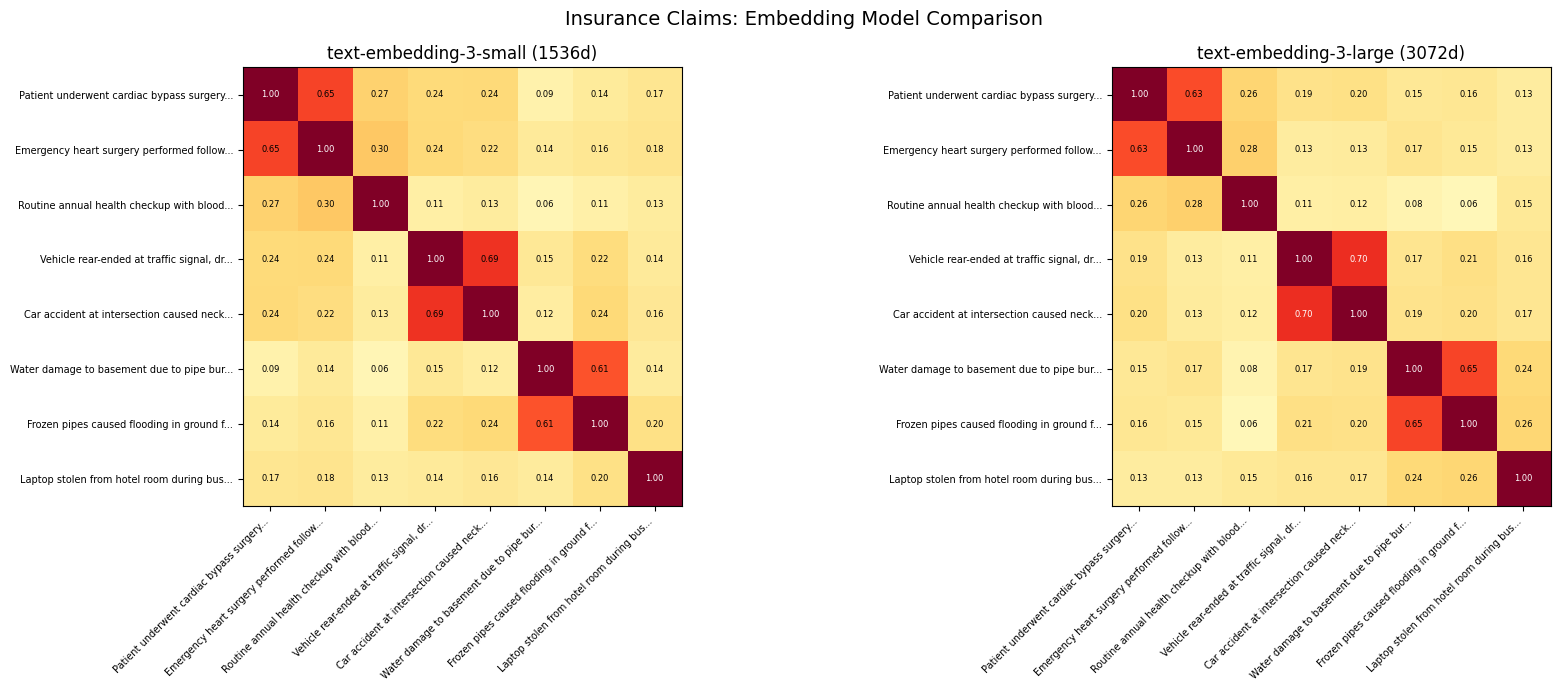

In [ ]:
# Visualize both similarity matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
labels = [c[:40] + "..." if len(c) > 40 else c for c in claims]

for ax, sim, title in [(axes[0], sim_small, "text-embedding-3-small (1536d)"),
                        (axes[1], sim_large, "text-embedding-3-large (3072d)")]:
    im = ax.imshow(sim, cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(title, fontsize=12)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{sim[i][j]:.2f}", ha='center', va='center',
                    fontsize=6, color='white' if sim[i][j] > 0.7 else 'black')

# plt.colorbar(im, ax=axes, label='Cosine Similarity', shrink=0.8)
plt.suptitle("Insurance Claims: Embedding Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

### Model Selection Guidelines

| Factor | `text-embedding-3-small` | `text-embedding-3-large` |
|--------|--------------------------|---------------------------|
| **Dimensions** | 1,536 | 3,072 |
| **Cost** | ~$0.02 / 1M tokens | ~$0.13 / 1M tokens |
| **Speed** | Faster | Slightly slower |
| **Quality** | Good for most tasks | Better for nuanced similarity |
| **Storage** | 2× less memory | 2× more memory |
| **Best for** | Prototyping, cost-sensitive apps | High-precision retrieval, production RAG |

---

## 6. Task 3 — Open-Source Embeddings with Sentence-Transformers

### Business Scenario
A healthcare startup wants to build a **patient FAQ matching system** but has budget constraints. They want to evaluate whether free, open-source embeddings can work well enough before committing to a paid API.

In [ ]:
from sentence_transformers import SentenceTransformer

# Load open-source model — runs locally, no API key needed
# st_model = SentenceTransformer('all-MiniLM-L6-v2')  # 384 dimensions, ~90MB
# print(f"Model loaded: all-MiniLM-L6-v2 (384 dimensions) ✅")

st_model = SentenceTransformer('mixedbread-ai/mxbai-embed-large-v1')  # 1024 dimensions, ~670MB
print(f"Model loaded: mxbai-embed-large-v1 (1024 dimensions) ✅")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Model loaded: all-MiniLM-L6-v2 (384 dimensions) ✅


In [ ]:
# Healthcare FAQ pairs — test if the model can match patient questions to FAQ answers
faq_questions = [
    "What are the side effects of metformin?",
    "How do I schedule a telehealth appointment?",
    "Is my MRI scan covered by insurance?",
    "What should I eat before a blood test?",
    "How do I refill my prescription online?",
]

# Patient queries (natural language, different wording)
patient_queries = [
    "I started taking metformin and I feel nauseous, is that normal?",
    "Can I see my doctor over video call instead of going to the clinic?",
    "Will my health plan pay for the imaging test my doctor ordered?",
    "Do I need to fast before getting my blood drawn tomorrow?",
    "I ran out of my medication, how can I get more without visiting the pharmacy?",
]

# Generate embeddings using both OpenAI and sentence-transformers
faq_emb_openai = get_openai_embeddings(faq_questions)
query_emb_openai = get_openai_embeddings(patient_queries)

faq_emb_st = st_model.encode(faq_questions)
query_emb_st = st_model.encode(patient_queries)

print(f"OpenAI embeddings: {faq_emb_openai.shape[1]}d")
print(f"Sentence-Transformers embeddings: {faq_emb_st.shape[1]}d")

OpenAI embeddings: 1536d
Sentence-Transformers embeddings: 1024d


In [ ]:
# Compare: which model correctly matches each patient query to its FAQ?
sim_openai = cosine_similarity(query_emb_openai, faq_emb_openai)
sim_st = cosine_similarity(query_emb_st, faq_emb_st)

print("🏥 FAQ Matching Comparison: OpenAI vs Sentence-Transformers\n")
print(f"{'Patient Query':<65} {'OpenAI Match':>14} {'ST Match':>10}")
print("─" * 91)

openai_correct = 0
st_correct = 0

for i in range(len(patient_queries)):
    oi_best = np.argmax(sim_openai[i])
    st_best = np.argmax(sim_st[i])

    # Ground truth: query i should match FAQ i
    oi_check = "✅" if oi_best == i else f"❌ (→{oi_best})"
    st_check = "✅" if st_best == i else f"❌ (→{st_best})"

    if oi_best == i: openai_correct += 1
    if st_best == i: st_correct += 1

    print(f"{patient_queries[i][:63]:<65} {oi_check:>14} {st_check:>10}")

print(f"\nAccuracy — OpenAI: {openai_correct}/{len(patient_queries)}, "
      f"Sentence-Transformers: {st_correct}/{len(patient_queries)}")

🏥 FAQ Matching Comparison: OpenAI vs Sentence-Transformers

Patient Query                                                       OpenAI Match   ST Match
───────────────────────────────────────────────────────────────────────────────────────────
I started taking metformin and I feel nauseous, is that normal?                ✅          ✅
Can I see my doctor over video call instead of going to the cli                ✅          ✅
Will my health plan pay for the imaging test my doctor ordered?                ✅          ✅
Do I need to fast before getting my blood drawn tomorrow?                      ✅          ✅
I ran out of my medication, how can I get more without visiting                ✅          ✅

Accuracy — OpenAI: 5/5, Sentence-Transformers: 5/5


### OpenAI vs Open-Source Embeddings

| Factor | OpenAI (`text-embedding-3-small`) | Sentence-Transformers (`all-MiniLM-L6-v2`) |
|--------|-----------------------------------|---------------------------------------------|
| **Cost** | ~$0.02 / 1M tokens | Free (runs locally) |
| **Dimensions** | 1,536 | 384 |
| **Latency** | Network round-trip (~200ms) | Local inference (~10ms) |
| **Quality** | State-of-the-art | Good for many tasks |
| **Privacy** | Data sent to API | Data stays local |
| **Offline use** | ❌ Requires internet | ✅ Works offline |

---
## 6a. NEW: AWS Bedrock — Titan Embed v2

If your data is on AWS (S3 / RDS / OpenSearch / Bedrock Knowledge Base), embedding via Titan v2 keeps everything in-VPC, in-region, with IAM-based access control. Two ways to call it:

- **Native `boto3` Bedrock Runtime** — direct API, full control over request/response.
- **`langchain_aws.BedrockEmbeddings`** — implements the LangChain `Embeddings` interface, drop-in replacement for `OpenAIEmbeddings` in any LangChain pipeline.


In [ ]:
# --- Native boto3 Bedrock Runtime ---
import boto3
import json as _json
import numpy as np

bedrock = boto3.client('bedrock-runtime', region_name=os.environ.get('AWS_DEFAULT_REGION', 'us-east-1'))

def titan_embed(text: str, dimensions: int = 1024, normalize: bool = True) -> list[float]:
    body = _json.dumps({
        'inputText': text,
        'dimensions': dimensions,   # 256, 512, or 1024 — picks lower-d slice of the same model
        'normalize': normalize,
    })
    resp = bedrock.invoke_model(
        modelId='amazon.titan-embed-text-v2:0',
        body=body,
        contentType='application/json',
        accept='application/json',
    )
    return _json.loads(resp['body'].read())['embedding']

vec = titan_embed('Personal loan with floating interest rate and zero prepayment charges')
print(f'Titan v2 embedding length: {len(vec)} (truncatable to 256 or 512)')
print(f'First 8 dims: {[round(x, 4) for x in vec[:8]]}')


In [ ]:
# --- LangChain BedrockEmbeddings wrapper ---
from langchain_aws import BedrockEmbeddings

titan = BedrockEmbeddings(
    client=bedrock,
    model_id='amazon.titan-embed-text-v2:0',
    model_kwargs={'dimensions': 1024, 'normalize': True},
)

# Same interface as OpenAIEmbeddings — `.embed_query` and `.embed_documents`
q_vec = titan.embed_query('What is the home loan interest rate?')
doc_vecs = titan.embed_documents([
    'Home loan rates are RPLR-linked, currently 8.5% p.a.',
    'Personal loan rates start at 12.5% p.a. for salaried customers.',
    'Fixed deposit rates: 7.0% for 1-year, 7.25% for 2-year tenures.',
])

# Cosine similarity (Titan returns normalised vectors → dot product = cosine)
sims = [float(np.dot(q_vec, d)) for d in doc_vecs]
for i, s in enumerate(sims):
    print(f'doc {i}: cosine = {s:.4f}')


### Titan v2 vs OpenAI text-embedding-3-small — Quick Comparison

| Dimension | Titan Embed v2 | OpenAI text-embedding-3-small |
|---|---|---|
| Default vector dim | 1024 (truncatable to 512 or 256) | 1536 (Matryoshka-truncatable) |
| Max input tokens | 8192 | 8191 |
| Approx price | ~$0.02 / 1M input tokens | ~$0.02 / 1M input tokens |
| Hosting | AWS Bedrock (in-VPC, IAM) | OpenAI hosted |
| Languages | 100+ | 100+ |
| Best for | AWS-native stacks, compliance/data-residency requirements | Mixed-cloud or non-AWS stacks; slightly better English benchmarks |
| Latency | Single-region; usually < 200 ms | Global edge; usually < 150 ms |

**Decision rule.** If your data lives on AWS and you need IAM/VPC isolation → Titan. Otherwise OpenAI is the simpler default and slightly stronger on most public English benchmarks.


---

## 7. Task 4 — Similarity Metrics Deep-Dive

### Business Scenario
An e-commerce platform wants to detect **duplicate product listings** from different sellers. We compare cosine similarity, dot product, and Euclidean distance to understand which metric works best.

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances

# E-commerce product listings — some are near-duplicates
listings = [
    "Apple iPhone 15 Pro Max 256GB Natural Titanium Unlocked",          # 0
    "iPhone 15 Pro Max 256 GB Titanium - Factory Unlocked Brand New",   # 1 (near-duplicate of 0)
    "Samsung Galaxy S24 Ultra 512GB Titanium Gray Unlocked",            # 2
    "Apple MacBook Pro 14-inch M3 Pro chip 18GB RAM 512GB SSD",         # 3
    "Sony WH-1000XM5 Wireless Noise Cancelling Headphones Black",      # 4
    "Bose QuietComfort Ultra Headphones Wireless Noise Cancelling",     # 5 (similar category to 4)
]

listing_embs = get_openai_embeddings(listings)

# Compute three similarity/distance metrics
cos_sim = cosine_similarity(listing_embs)
dot_prod = listing_embs @ listing_embs.T  # dot product
euc_dist = euclidean_distances(listing_embs)

# Compare metrics for key pairs
pairs = [
    (0, 1, "iPhone 15 Pro Max (duplicate listing)"),
    (0, 2, "iPhone vs Samsung (same category, diff brand)"),
    (4, 5, "Sony vs Bose headphones (competitor products)"),
    (0, 3, "iPhone vs MacBook (same brand, diff product)"),
    (0, 4, "iPhone vs Headphones (unrelated)"),
]

print("📊 Similarity Metrics Comparison\n")
print(f"{'Pair':<50} {'Cosine':>8} {'Dot Prod':>10} {'Euclidean':>10}")
print("─" * 80)
for i, j, label in pairs:
    print(f"{label:<50} {cos_sim[i][j]:>8.4f} {dot_prod[i][j]:>10.4f} {euc_dist[i][j]:>10.4f}")

📊 Similarity Metrics Comparison

Pair                                                 Cosine   Dot Prod  Euclidean
────────────────────────────────────────────────────────────────────────────────
iPhone 15 Pro Max (duplicate listing)                0.8763     0.8763     0.4973
iPhone vs Samsung (same category, diff brand)        0.6701     0.6701     0.8123
Sony vs Bose headphones (competitor products)        0.6493     0.6493     0.8375
iPhone vs MacBook (same brand, diff product)         0.5000     0.5000     1.0000
iPhone vs Headphones (unrelated)                     0.3060     0.3060     1.1781


### When to Use Which Metric

| Metric | Formula | Range | Best For |
|--------|---------|-------|----------|
| **Cosine Similarity** | cos(θ) = (A·B) / (‖A‖‖B‖) | [-1, 1] | Comparing semantic meaning regardless of text length |
| **Dot Product** | A·B = Σ(aᵢ × bᵢ) | (-∞, +∞) | When magnitude matters (e.g., document importance) |
| **Euclidean Distance** | ‖A - B‖₂ | [0, +∞) | When you need absolute distance (lower = more similar) |

> **For most NLP tasks, cosine similarity is the standard choice** — it normalizes for vector magnitude, focusing purely on directional similarity.

---

## 8. Task 5 — 2D Visualization of Embedding Space

### Business Scenario
A marketing team at a multi-line insurer wants to understand how their different product brochure texts relate to each other. We use t-SNE to project high-dimensional embeddings into 2D for visual exploration.

In [ ]:
# Multi-domain texts for visualization
texts_with_categories = [
    # Health Insurance
    ("Comprehensive health coverage including hospitalization and surgery", "Health Insurance"),
    ("Family health plan with cashless treatment at 5000+ hospitals", "Health Insurance"),
    ("Critical illness rider covering cancer, heart attack, stroke", "Health Insurance"),
    # Life Insurance
    ("Term life insurance with 1 crore coverage at affordable premiums", "Life Insurance"),
    ("Whole life policy with guaranteed returns and death benefit", "Life Insurance"),
    ("Child education plan with life cover and maturity benefits", "Life Insurance"),
    # Auto Insurance
    ("Comprehensive car insurance with zero depreciation and roadside assistance", "Auto Insurance"),
    ("Third-party motor vehicle liability coverage as per regulations", "Auto Insurance"),
    ("Two-wheeler insurance with theft protection and personal accident cover", "Auto Insurance"),
    # Home Insurance
    ("Home contents insurance covering fire, theft, and natural disasters", "Home Insurance"),
    ("Property insurance for structural damage including earthquake coverage", "Home Insurance"),
    ("Renters insurance for personal belongings and liability protection", "Home Insurance"),
]

texts = [t[0] for t in texts_with_categories]
categories = [t[1] for t in texts_with_categories]

# Generate embeddings
all_embs = get_openai_embeddings(texts)
print(f"Generated embeddings: {all_embs.shape}")

Generated embeddings: (12, 1536)


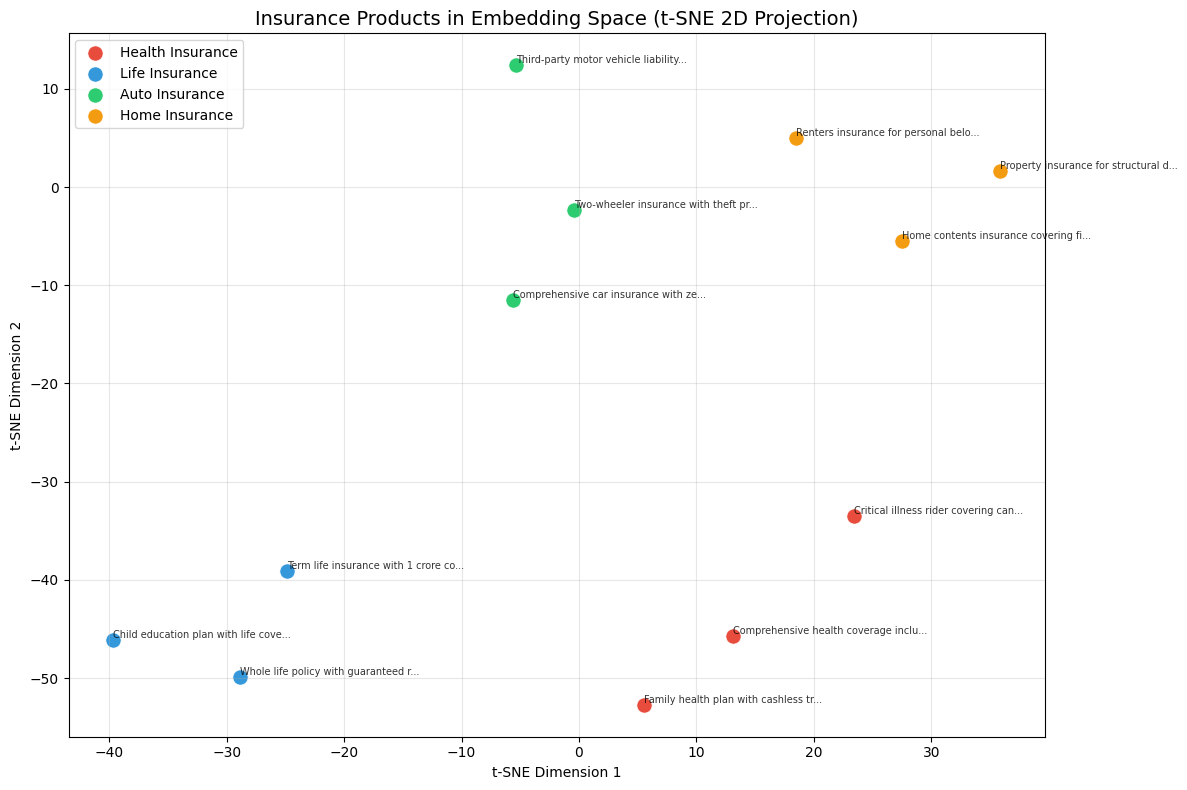

In [ ]:
# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=4)
coords = tsne.fit_transform(all_embs)

# Plot with color-coded categories
color_map = {"Health Insurance": "#e74c3c", "Life Insurance": "#3498db",
             "Auto Insurance": "#2ecc71", "Home Insurance": "#f39c12"}

plt.figure(figsize=(12, 8))
for cat in color_map:
    mask = [c == cat for c in categories]
    pts = coords[mask]
    plt.scatter(pts[:, 0], pts[:, 1], c=color_map[cat], label=cat, s=120, edgecolors='white', linewidth=0.5)

# Annotate points with truncated text
for i, txt in enumerate(texts):
    plt.annotate(txt[:35] + "...", (coords[i, 0], coords[i, 1]),
                 fontsize=7, ha='left', va='bottom', alpha=0.8)

plt.legend(fontsize=10)
plt.title("Insurance Products in Embedding Space (t-SNE 2D Projection)", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What to look for:** Products within the same category (same color) should cluster together, while different categories should be separated. This visual confirms that embeddings capture semantic groupings — the foundation for clustering (Lab 3) and retrieval (Lab 2).

---
## 9. Build the Document Corpus

We move from raw embeddings to a real vector store. Build a small corpus of mixed-domain documents (banking + general).

## 4. Build the Document Corpus

### Business Scenario
A **large retail bank** has an internal knowledge base with hundreds of documents covering products, policies, compliance guidelines, and customer FAQs. We simulate this by creating a realistic corpus of ~300 short documents across multiple banking domains.

We generate part of the corpus programmatically and supplement with manually-curated entries for controlled testing.

In [ ]:
# Manually curated core documents across banking domains
# These give us known ground-truth for retrieval evaluation later

core_documents = [
    # --- Savings & Deposits (0-19) ---
    "Our Premium Savings Account offers 4.5% APY with no minimum balance requirement and is FDIC insured up to $250,000.",
    "The Youth Savings Account is designed for customers aged 13-25, with no monthly fees and a 3.2% interest rate.",
    "Fixed deposits are available with tenures ranging from 6 months to 5 years. Early withdrawal incurs a 1% penalty on earned interest.",
    "Senior Citizen Savings Scheme offers an additional 0.50% interest rate above regular FD rates for customers over 60.",
    "Our recurring deposit plan allows monthly contributions of $50 to $10,000 with auto-debit from your checking account.",
    "The money market account requires a $2,500 minimum balance and provides check-writing privileges with 4.1% APY.",
    "Certificate of Deposit (CD) rates: 6-month at 4.0%, 12-month at 4.3%, 24-month at 4.5%, 60-month at 4.8%.",
    "Interest on savings accounts is compounded daily and credited monthly. Rate is variable and subject to change.",
    "Joint savings accounts allow up to 4 co-holders with equal rights. All holders must present valid ID at branch.",
    "Our zero-balance savings account is available for salaried individuals with direct deposit setup from their employer.",
    # --- Loans (10-19) ---
    "Home loans are available at 6.5% fixed rate for up to 30 years. Minimum down payment is 10% for first-time buyers.",
    "Personal loans range from $1,000 to $50,000 with terms of 12-60 months. No collateral required for loans under $25,000.",
    "Auto loans offer competitive rates starting at 5.9% APR for new vehicles and 6.9% for used vehicles up to 5 years old.",
    "Student education loans cover tuition, books, housing, and living expenses. Repayment begins 6 months after graduation.",
    "Business term loans are available from $25,000 to $500,000 with fixed or variable rate options for established businesses.",
    "Home equity line of credit (HELOC) allows borrowing against your home's equity at prime rate plus 1.5%.",
    "Loan refinancing options are available for existing customers looking to reduce their monthly EMI or interest rate.",
    "Agricultural loans support farming equipment purchase, crop financing, and land improvement projects at subsidized rates.",
    "Debt consolidation loans combine multiple high-interest debts into a single monthly payment at lower interest rates.",
    "Bridge loans provide short-term financing for 6-12 months while customers transition between property purchases.",
    # --- Credit Cards (20-29) ---
    "The Platinum Credit Card offers 3% cashback on dining, 2% on travel, and 1% on all other purchases with no annual fee for the first year.",
    "Our Business Credit Card provides 5x reward points on office supplies, telecom, and cloud services for small businesses.",
    "The Student Credit Card has a $1,000 credit limit with no annual fee and 1.5% cashback on all purchases.",
    "Premium travel card includes complimentary airport lounge access at 1000+ lounges worldwide and travel insurance up to $500,000.",
    "Credit card balance transfer facility available at 0% APR for first 15 months. Transfer fee is 3% of amount transferred.",
    "Contactless payments are enabled on all credit cards. Daily contactless transaction limit is $500 without PIN.",
    "Credit card EMI conversion is available for transactions above $200. Convert to 3, 6, 9, or 12-month installments.",
    "Card replacement for lost or stolen cards is free. Emergency card issuance within 48 hours at any branch.",
    "Credit limit increase requests can be submitted online. Processing takes 3-5 business days with no impact on credit score.",
    "All credit cards come with fraud protection. Unauthorized transactions reported within 48 hours result in zero liability.",
    # --- Digital Banking (30-39) ---
    "Mobile banking app supports fingerprint and face ID login, instant fund transfers, bill payments, and investment tracking.",
    "Online account opening requires a valid government-issued photo ID and can be completed in under 10 minutes.",
    "UPI payments are supported with daily transaction limits of $2,000 for peer-to-peer and $5,000 for merchant payments.",
    "Digital wallet integration supports Apple Pay, Google Pay, and Samsung Pay for contactless in-store payments.",
    "Net banking platform provides account statements, tax certificates, and loan account details downloadable as PDF.",
    "Two-factor authentication is mandatory for all online transactions above $100. OTP is sent via SMS and email.",
    "Scheduled recurring payments can be set up for rent, utilities, subscriptions, and loan EMIs via net banking.",
    "The chatbot assistant is available 24/7 for balance inquiries, recent transactions, and basic service requests.",
    "Remote deposit capture allows check deposits via mobile app by photographing the front and back of the check.",
    "Account alerts can be configured for low balance warnings, large transactions, login attempts, and payment reminders.",
    # --- Insurance Products (40-49) ---
    "Term life insurance policies available from $100,000 to $5 million coverage with premiums starting at $15/month.",
    "Health insurance family floater plan covers spouse and up to 3 children with cashless hospitalization at network hospitals.",
    "Comprehensive car insurance covers own damage, third-party liability, personal accident, and roadside assistance.",
    "Home insurance protects against fire, theft, natural disasters, and accidental damage to structure and contents.",
    "Travel insurance covers medical emergencies abroad, trip cancellation, delayed flights, and lost baggage up to $50,000.",
    "Critical illness insurance pays a lump sum on diagnosis of cancer, heart attack, stroke, or organ transplant.",
    "Professional liability insurance for doctors, lawyers, and consultants covers malpractice claims up to $2 million.",
    "Cyber insurance for businesses covers data breach costs, ransomware payments, and business interruption losses.",
    "Pet insurance covers veterinary bills, surgery, hospitalization, and preventive care for dogs and cats.",
    "Group health insurance for companies with 10+ employees offers discounted premiums and customizable coverage options.",
    # --- Compliance & Policies (50-59) ---
    "KYC verification requires government-issued photo ID, proof of address not older than 3 months, and a recent photograph.",
    "Anti-money laundering (AML) policy requires reporting of all cash transactions exceeding $10,000 to the regulatory authority.",
    "Customer complaint resolution turnaround time is 7 business days for standard complaints and 24 hours for fraud-related issues.",
    "Account dormancy policy: accounts with no transactions for 24 months are classified as dormant and require reactivation.",
    "GDPR compliance ensures all customer data is encrypted at rest and in transit. Data deletion requests are processed within 30 days.",
    "Wire transfer processing: domestic transfers complete within same business day. International wires take 2-5 business days.",
    "Check clearance timeline: local checks clear in 1-2 business days. Outstation checks may take up to 5 business days.",
    "Safe deposit box rental is available in three sizes: small ($60/year), medium ($120/year), and large ($250/year).",
    "Nomination facility is available for savings accounts, fixed deposits, and locker services. Nomination can be changed anytime at branch.",
    "Power of attorney holders can operate accounts with notarized POA document. POA does not apply to locker access.",
]

print(f"Core documents: {len(core_documents)}")

Core documents: 60


In [ ]:
# Generate additional documents using gpt-4.1-mini to reach 300+
# We ask the model to generate domain-specific banking knowledge base entries

def generate_documents_batch(domain, count, existing_count):
    """Generate a batch of banking knowledge base documents using OpenAI Responses API."""
    response = openai_client.responses.create(
        model="gpt-4.1-mini",
        instructions="You are a banking knowledge base content writer. Generate realistic, factual-sounding bank KB articles.",
        input=f"""Generate exactly {count} short knowledge base entries (1-2 sentences each) about: {domain}.
Each entry should be a standalone fact or policy statement that a bank customer might search for.
Return ONLY a JSON array of strings, no other text.
Example format: ["Entry one text.", "Entry two text."]""",
        temperature=0.8
    )
    try:
        # Parse the JSON array from the response
        text = response.output_text.strip()
        # Handle markdown code blocks if present
        if text.startswith("```"):
            text = text.split("```")[1]
            if text.startswith("json"):
                text = text[4:]
        return json.loads(text)
    except (json.JSONDecodeError, IndexError) as e:
        print(f"  ⚠️ Parse error for {domain}: {e}")
        return []

# Generate additional documents across banking sub-domains
domains = [
    ("wealth management and mutual fund investment advice", 30),
    ("mortgage and property financing rules and guidelines", 25),
    ("international banking, forex, and remittance services", 25),
    ("customer service policies, branch operations, and account management", 25),
    ("business banking, trade finance, and corporate services", 25),
    ("retirement planning, pension accounts, and senior citizen services", 25),
    ("fraud prevention, cybersecurity, and safe banking practices", 25),
    ("tax-saving instruments, deductions, and financial planning", 20),
    ("debit card features, ATM services, and transaction limits", 20),
    ("NRI banking services, overseas accounts, and repatriation rules", 20),
]

generated_docs = []
for domain, count in domains:
    print(f"⏳ Generating {count} docs for: {domain[:50]}...")
    batch = generate_documents_batch(domain, count, len(core_documents) + len(generated_docs))
    generated_docs.extend(batch)
    print(f"   ✅ Got {len(batch)} documents")

# Combine all documents
all_documents = core_documents + generated_docs
print(f"\n📚 Total corpus size: {len(all_documents)} documents")

⏳ Generating 30 docs for: wealth management and mutual fund investment advic...
   ✅ Got 29 documents
⏳ Generating 25 docs for: mortgage and property financing rules and guidelin...
   ✅ Got 25 documents
⏳ Generating 25 docs for: international banking, forex, and remittance servi...
   ✅ Got 25 documents
⏳ Generating 25 docs for: customer service policies, branch operations, and ...
   ✅ Got 25 documents
⏳ Generating 25 docs for: business banking, trade finance, and corporate ser...
   ✅ Got 25 documents
⏳ Generating 25 docs for: retirement planning, pension accounts, and senior ...
   ✅ Got 25 documents
⏳ Generating 25 docs for: fraud prevention, cybersecurity, and safe banking ...
   ✅ Got 25 documents
⏳ Generating 20 docs for: tax-saving instruments, deductions, and financial ...
   ✅ Got 20 documents
⏳ Generating 20 docs for: debit card features, ATM services, and transaction...
   ✅ Got 20 documents
⏳ Generating 20 docs for: NRI banking services, overseas accounts, and repat...
  

## 10. Embed the Corpus

## 5. Embed the Entire Corpus

We embed all documents in batches (OpenAI allows up to 2048 inputs per call with a max of 300K total tokens).

In [ ]:
def embed_corpus(documents, model="text-embedding-3-small", batch_size=100):
    """
    Embed a list of documents in batches.
    Returns numpy array of all embeddings.
    """
    all_embeddings = []
    for i in range(0, len(documents), batch_size):
        batch = documents[i:i + batch_size]
        response = openai_client.embeddings.create(
            model=model,
            input=batch
        )
        batch_embs = [item.embedding for item in response.data]
        all_embeddings.extend(batch_embs)
        print(f"  Embedded batch {i//batch_size + 1}: docs {i}–{i+len(batch)-1}")
    return np.array(all_embeddings, dtype='float32')  # float32 for FAISS

print("Embedding entire corpus...")
start = time.time()
corpus_embeddings = embed_corpus(all_documents)
elapsed = round(time.time() - start, 2)

print(f"\n✅ Embedded {len(all_documents)} documents in {elapsed}s")
print(f"Embedding matrix shape: {corpus_embeddings.shape}")

Embedding entire corpus...
  Embedded batch 1: docs 0–99
  Embedded batch 2: docs 100–199
  Embedded batch 3: docs 200–298

✅ Embedded 299 documents in 1.21s
Embedding matrix shape: (299, 1536)


---
## 11. FAISS In-Memory Vector Store

FAISS (Facebook AI Similarity Search) is the workhorse in-process vector index — written in C++, extremely fast, supports exact and approximate search, runs entirely in your Python process. Best for: in-process search, small-to-medium corpora (up to ~10M vectors), low-latency requirements.

### Building & Searching the Index

## 6. Build the FAISS Vector Index

FAISS (Facebook AI Similarity Search) is an open-source library for efficient similarity search. It supports multiple index types — we start with `IndexFlatIP` (exact inner product / cosine similarity search) and then show an approximate index for scale.

In [ ]:
def build_faiss_index(embeddings, use_cosine=True):
    """
    Build a FAISS index.
    For cosine similarity: normalize vectors then use inner product (IP) index.
    """
    dim = embeddings.shape[1]

    if use_cosine:
        # L2-normalize vectors so that inner product = cosine similarity
        faiss.normalize_L2(embeddings)
        index = faiss.IndexFlatIP(dim)  # Inner Product (= cosine after normalization)
    else:
        index = faiss.IndexFlatL2(dim)  # Euclidean distance

    index.add(embeddings)
    return index

# Build the index
faiss_index = build_faiss_index(corpus_embeddings.copy())  # .copy() because normalize_L2 is in-place
print(f"FAISS index built: {faiss_index.ntotal} vectors, {corpus_embeddings.shape[1]} dimensions ✅")

FAISS index built: 299 vectors, 1536 dimensions ✅


## 7. Search the Index — Semantic Retrieval

### Business Scenario
A bank's customer service agent types a natural language query into the internal search tool. The system should return the most relevant knowledge base articles.

In [ ]:
def semantic_search(query, index, documents, model="text-embedding-3-small", top_k=5):
    """
    Search the FAISS index with a natural language query.
    Returns top_k most similar documents with scores.
    """
    # Embed the query
    response = openai_client.embeddings.create(model=model, input=[query])
    query_emb = np.array([response.data[0].embedding], dtype='float32')
    faiss.normalize_L2(query_emb)  # Match the normalization of indexed vectors

    # Search
    scores, indices = index.search(query_emb, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "rank": len(results) + 1,
            "score": float(score),
            "doc_id": int(idx),
            "text": documents[idx]
        })
    return results


def display_search_results(query, results):
    """Pretty-print search results."""
    print(f"\n{'='*70}")
    print(f"🔍 Query: \"{query}\"")
    print(f"{'='*70}")
    for r in results:
        print(f"  #{r['rank']} [score: {r['score']:.4f}] (doc #{r['doc_id']})")
        print(f"     {r['text'][:120]}{'...' if len(r['text']) > 120 else ''}")
    print()

In [ ]:
# Test queries — spanning multiple banking domains
test_queries = [
    "What interest rate can I get on a savings account?",
    "I need a loan to buy my first home",
    "How do I report a stolen credit card?",
    "What documents are needed to open an account?",
    "Is my money safe if the bank fails?",
    "I want to send money to my family abroad",
    "What insurance covers hospital bills for my family?",
    "How can I save on taxes this year?",
]

for query in test_queries:
    results = semantic_search(query, faiss_index, all_documents, top_k=3)
    display_search_results(query, results)


🔍 Query: "What interest rate can I get on a savings account?"
  #1 [score: 0.6275] (doc #7)
     Interest on savings accounts is compounded daily and credited monthly. Rate is variable and subject to change.
  #2 [score: 0.6031] (doc #1)
     The Youth Savings Account is designed for customers aged 13-25, with no monthly fees and a 3.2% interest rate.
  #3 [score: 0.5287] (doc #3)
     Senior Citizen Savings Scheme offers an additional 0.50% interest rate above regular FD rates for customers over 60.


🔍 Query: "I need a loan to buy my first home"
  #1 [score: 0.4982] (doc #10)
     Home loans are available at 6.5% fixed rate for up to 30 years. Minimum down payment is 10% for first-time buyers.
  #2 [score: 0.4615] (doc #100)
     First-time homebuyer programs may offer reduced down payments or special interest rates subject to eligibility.
  #3 [score: 0.4334] (doc #91)
     The maximum loan-to-value (LTV) ratio for a primary residence is typically 80%, requiring a 20% down payment.

---
## 12. Semantic Search vs Keyword Search (TF-IDF Baseline)

## 8. Semantic Search vs Keyword Search

### Business Scenario
The bank's existing search tool uses keyword matching (TF-IDF). We compare it with our semantic search to demonstrate the value upgrade.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def keyword_search(query, documents, top_k=5):
    """
    Simple TF-IDF keyword search for comparison.
    """
    # Fit TF-IDF on corpus + query
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(documents + [query])

    # Compute cosine similarity between query and all documents
    from sklearn.metrics.pairwise import cosine_similarity
    query_vec = tfidf_matrix[-1]  # Last vector is the query
    doc_vecs = tfidf_matrix[:-1]  # All other vectors are documents
    similarities = cosine_similarity(query_vec, doc_vecs).flatten()

    # Get top-k indices
    top_indices = similarities.argsort()[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_indices):
        results.append({
            "rank": rank + 1,
            "score": float(similarities[idx]),
            "doc_id": int(idx),
            "text": documents[idx]
        })
    return results

In [ ]:
# Head-to-head comparison on queries that test semantic understanding
comparison_queries = [
    "I want to grow my money safely",           # No keyword overlap with "savings account" or "APY"
    "My kid is going to college next year",      # Should find education loan, not just keyword "college"
    "I got into a car crash and need help",      # Should find auto insurance, not just keyword "car"
]

for query in comparison_queries:
    sem_results = semantic_search(query, faiss_index, all_documents, top_k=3)
    kw_results = keyword_search(query, all_documents, top_k=3)

    print(f"\n{'='*80}")
    print(f"🔍 Query: \"{query}\"")
    print(f"{'='*80}")

    print(f"\n  🧠 SEMANTIC SEARCH (embedding-based):")
    for r in sem_results:
        print(f"    #{r['rank']} [{r['score']:.3f}] {r['text'][:100]}...")

    print(f"\n  📝 KEYWORD SEARCH (TF-IDF):")
    for r in kw_results:
        print(f"    #{r['rank']} [{r['score']:.3f}] {r['text'][:100]}...")


🔍 Query: "I want to grow my money safely"

  🧠 SEMANTIC SEARCH (embedding-based):
    #1 [0.394] Investing early and consistently in mutual funds helps take advantage of compounding over time....
    #2 [0.358] Tax planning through systematic investment in tax-saving instruments should align with your long-ter...
    #3 [0.347] Using a bank’s remittance service can offer more security than informal money transfer methods....

  📝 KEYWORD SEARCH (TF-IDF):
    #1 [0.123] Using a bank’s remittance service can offer more security than informal money transfer methods....
    #2 [0.122] Remittance services enable customers to send money securely to recipients in other countries....
    #3 [0.118] Banks typically require identification documents to comply with international anti-money laundering ...

🔍 Query: "My kid is going to college next year"

  🧠 SEMANTIC SEARCH (embedding-based):
    #1 [0.284] Student education loans cover tuition, books, housing, and living expenses. Repayment begin

### 💡 Key Observation
Semantic search retrieves relevant results even when the query uses completely different words than the document. "Grow my money safely" → finds savings/FD products. Keyword search would miss this because there's no word overlap.

---
## 13. Retrieval Quality Evaluation (Recall@k, MRR)

## 9. Retrieval Quality Evaluation

### Business Scenario
Before deploying the search engine to production, the QA team needs to measure how well it performs. We compute standard Information Retrieval metrics: **Precision@K**, **Recall@K**, and **MRR** (Mean Reciprocal Rank).

In [ ]:
# Define evaluation queries with known relevant document IDs (ground truth)
# These reference our core_documents (indices 0-59)
eval_queries = [
    {
        "query": "What is the interest rate on savings accounts?",
        "relevant_docs": [0, 1, 7, 9],  # Savings-related docs
    },
    {
        "query": "I need financing to purchase a house",
        "relevant_docs": [10, 15, 19],  # Home loan, HELOC, bridge loan
    },
    {
        "query": "Credit card fraud protection and lost card",
        "relevant_docs": [27, 29],  # Card replacement, fraud protection
    },
    {
        "query": "How to set up online banking and make transfers",
        "relevant_docs": [30, 32, 34, 36],  # Digital banking docs
    },
    {
        "query": "Health insurance that covers my whole family",
        "relevant_docs": [41, 49],  # Family health plan, group health
    },
    {
        "query": "KYC requirements and account opening process",
        "relevant_docs": [50, 31],  # KYC, online account opening
    },
]


def precision_at_k(retrieved_ids, relevant_ids, k):
    """What fraction of the top-K retrieved docs are actually relevant?"""
    top_k = retrieved_ids[:k]
    relevant_in_topk = len(set(top_k) & set(relevant_ids))
    return relevant_in_topk / k


def recall_at_k(retrieved_ids, relevant_ids, k):
    """What fraction of all relevant docs appear in top-K?"""
    top_k = retrieved_ids[:k]
    relevant_in_topk = len(set(top_k) & set(relevant_ids))
    return relevant_in_topk / len(relevant_ids) if relevant_ids else 0


def reciprocal_rank(retrieved_ids, relevant_ids):
    """1/rank of the first relevant doc in the retrieved list."""
    for rank, doc_id in enumerate(retrieved_ids, 1):
        if doc_id in relevant_ids:
            return 1.0 / rank
    return 0.0

In [ ]:
# Run evaluation
K = 5
eval_results = []

for eq in eval_queries:
    results = semantic_search(eq["query"], faiss_index, all_documents, top_k=K)
    retrieved_ids = [r["doc_id"] for r in results]
    relevant_ids = eq["relevant_docs"]

    p_at_k = precision_at_k(retrieved_ids, relevant_ids, K)
    r_at_k = recall_at_k(retrieved_ids, relevant_ids, K)
    rr = reciprocal_rank(retrieved_ids, relevant_ids)

    eval_results.append({
        "Query": eq["query"][:50] + "...",
        f"P@{K}": round(p_at_k, 3),
        f"R@{K}": round(r_at_k, 3),
        "RR": round(rr, 3),
        "Retrieved": retrieved_ids,
        "Relevant": relevant_ids,
    })

eval_df = pd.DataFrame(eval_results)
print(f"📊 Retrieval Evaluation (K={K})\n")
display(eval_df[["Query", f"P@{K}", f"R@{K}", "RR"]])

# Compute aggregate metrics
avg_precision = eval_df[f"P@{K}"].mean()
avg_recall = eval_df[f"R@{K}"].mean()
mrr = eval_df["RR"].mean()
print(f"\n📈 Aggregate Metrics:")
print(f"   Mean Precision@{K}: {avg_precision:.3f}")
print(f"   Mean Recall@{K}:    {avg_recall:.3f}")
print(f"   MRR:                {mrr:.3f}")

📊 Retrieval Evaluation (K=5)



,Query,P@5,R@5,RR
0,What is the interest rate on savings accounts?...,0.4,0.500,1.000
1,I need financing to purchase a house...,0.4,0.667,0.333
2,Credit card fraud protection and lost card...,0.4,1.000,1.000
3,How to set up online banking and make transfer...,0.2,0.250,0.200
4,Health insurance that covers my whole family...,0.4,1.000,1.000
5,KYC requirements and account opening process...,0.4,1.000,1.000



📈 Aggregate Metrics:
   Mean Precision@5: 0.367
   Mean Recall@5:    0.736
   MRR:                0.756


### Metric Interpretation

| Metric | What It Measures | Good Score |
|--------|-----------------|------------|
| **Precision@K** | Of the K results shown, how many are relevant? | > 0.4 for broad KB |
| **Recall@K** | Of all relevant docs, how many did we find in top-K? | > 0.5 |
| **MRR** | How high is the first relevant result ranked? (1.0 = rank 1) | > 0.7 |

---
## 14. Scaling Up — Approximate Nearest Neighbor (ANN) Indexes

## 10. Scaling Up — Approximate Nearest Neighbor (ANN) Index

The flat index we built searches every vector (exact search). For millions of documents, this is too slow. FAISS offers approximate indexes that trade a small amount of accuracy for massive speed gains.

In [ ]:
# Compare exact vs approximate search speed
dim = corpus_embeddings.shape[1]

# Exact index (what we built earlier)
exact_embs = corpus_embeddings.copy()
faiss.normalize_L2(exact_embs)
exact_index = faiss.IndexFlatIP(dim)
exact_index.add(exact_embs)

# Approximate index (IVF = Inverted File Index with coarse quantizer)
n_docs = len(all_documents)
nlist = min(16, n_docs // 5)  # Number of clusters (Voronoi cells)
quantizer = faiss.IndexFlatIP(dim)
ivf_index = faiss.IndexIVFFlat(quantizer, dim, nlist, faiss.METRIC_INNER_PRODUCT)

approx_embs = corpus_embeddings.copy()
faiss.normalize_L2(approx_embs)
ivf_index.train(approx_embs)  # IVF requires training
ivf_index.add(approx_embs)
ivf_index.nprobe = 4  # Search 4 out of nlist clusters (speed vs accuracy tradeoff)

print(f"Exact index:  {exact_index.ntotal} vectors")
print(f"IVF index:    {ivf_index.ntotal} vectors, {nlist} clusters, nprobe={ivf_index.nprobe}")

# Benchmark search speed
test_query = "retirement savings plan with tax benefits"
response = openai_client.embeddings.create(model="text-embedding-3-small", input=[test_query])
q_emb = np.array([response.data[0].embedding], dtype='float32')
faiss.normalize_L2(q_emb)

# Exact search
start = time.time()
for _ in range(100):
    exact_index.search(q_emb, 5)
exact_time = (time.time() - start) / 100 * 1000  # ms per query

# Approximate search
start = time.time()
for _ in range(100):
    ivf_index.search(q_emb, 5)
approx_time = (time.time() - start) / 100 * 1000  # ms per query

print(f"\n⏱️ Search Speed (avg over 100 queries):")
print(f"   Exact:       {exact_time:.3f} ms/query")
print(f"   Approximate: {approx_time:.3f} ms/query")
print(f"   Speedup:     {exact_time/approx_time:.1f}x")
print(f"\n💡 With {n_docs} docs, the speedup is modest. At 1M+ docs, IVF indexes are 10-100x faster.")

Exact index:  299 vectors
IVF index:    299 vectors, 16 clusters, nprobe=4

⏱️ Search Speed (avg over 100 queries):
   Exact:       0.113 ms/query
   Approximate: 0.046 ms/query
   Speedup:     2.5x

💡 With 299 docs, the speedup is modest. At 1M+ docs, IVF indexes are 10-100x faster.


### FAISS Index Types Cheat Sheet

| Index Type | Search Type | Speed | Accuracy | Memory | Best For |
|------------|------------|-------|----------|--------|----------|
| `IndexFlatIP` | Exact | Slow at scale | 100% | High | < 100K docs |
| `IndexIVFFlat` | Approximate | Fast | ~95-99% | High | 100K–10M docs |
| `IndexIVFPQ` | Approximate | Very fast | ~90-95% | Low (compressed) | 10M+ docs |
| `IndexHNSW` | Approximate | Very fast | ~98% | High | When accuracy matters |

---
## 15. NEW: ChromaDB — Persistent Vector Store with Metadata Filtering

**FAISS limitation.** It's a pure index — no metadata filtering, no document store, no built-in persistence beyond `save_local()`/`load_local()`. To persist *and* filter on metadata (e.g., "only retrieve from the *2024 Compliance* policy doc"), use **ChromaDB**.

**ChromaDB** is an open-source embedding database. It stores documents + embeddings + metadata together, auto-persists to disk, and supports `where=` filters at query time. The trade is ~2-3× slower per query than FAISS — fine for typical RAG QPS.

We'll use the LangChain `Chroma` wrapper, which gives us `add_documents()`, `similarity_search()`, and `as_retriever()` — same API surface as the other vector stores.


In [ ]:
# Build a small banking-policy corpus with rich metadata for filtering demos.
from langchain_core.documents import Document

policy_docs = [
    Document(page_content='Personal loan rates are RPLR-linked at 12.5% p.a. for salaried customers.',
             metadata={'doc_type': 'policy', 'product': 'personal_loan', 'version': '2024.3', 'audience': 'salaried'}),
    Document(page_content='Self-employed personal loan applicants pay an additional 0.5% premium.',
             metadata={'doc_type': 'policy', 'product': 'personal_loan', 'version': '2024.3', 'audience': 'self_employed'}),
    Document(page_content='Home loan rates are linked to RPLR, currently 8.5% p.a. for tenures up to 30 years.',
             metadata={'doc_type': 'policy', 'product': 'home_loan', 'version': '2024.3', 'audience': 'all'}),
    Document(page_content='Fixed deposit interest: 7.0% for 1-year, 7.25% for 2-year, 7.5% for 5-year tenures.',
             metadata={'doc_type': 'rate_card', 'product': 'fixed_deposit', 'version': '2024.4', 'audience': 'all'}),
    Document(page_content='Credit card late-payment fee is ₹500 or 5% of due amount, whichever is lower.',
             metadata={'doc_type': 'fee_schedule', 'product': 'credit_card', 'version': '2023.1', 'audience': 'all'}),
]


In [ ]:
# Build a persistent Chroma collection — files live under ./chroma_db/
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

openai_embeddings = OpenAIEmbeddings(model='text-embedding-3-small')

chroma_store = Chroma.from_documents(
    documents=policy_docs,
    embedding=openai_embeddings,
    collection_name='banking_policies',
    persist_directory='./chroma_db',
)

print(f'Chroma collection size: {chroma_store._collection.count()}')
print('Persisted to ./chroma_db — survives kernel restart.')


In [ ]:
# --- Plain semantic search (no filter) ---
query = 'what is the interest rate for self-employed applicants?'
for doc in chroma_store.similarity_search(query, k=2):
    print(f'[{doc.metadata["product"]}/{doc.metadata["audience"]}] {doc.page_content}')


In [ ]:
# --- Metadata-filtered search: only the latest policy version ---
filtered = chroma_store.similarity_search(
    query='what are the loan rates?',
    k=3,
    filter={'version': '2024.3'},   # exact-match filter on metadata
)
for doc in filtered:
    print(f'[{doc.metadata["version"]}] [{doc.metadata["product"]}] {doc.page_content}')


In [ ]:
# --- Compound filter: home_loan only, any version ---
compound = chroma_store.similarity_search(
    query='loan interest rate',
    k=3,
    filter={'product': 'home_loan'},
)
for doc in compound:
    print(f'[{doc.metadata["product"]}] {doc.page_content}')

# Chroma also supports $eq, $ne, $in, $and, $or operators:
# filter={'$and': [{'doc_type': 'policy'}, {'version': '2024.3'}]}


### Where metadata filtering beats post-filtering

**Naive approach (post-filter).** Retrieve top-50 by similarity, then drop everything that doesn't match `version=2024.3`. Problem: if only 1 of your top-50 matches, you've wasted 49 retrievals and may return zero results.

**Vector-store-side filter (this section).** ChromaDB filters *before* the similarity search — your top-k comes from the *eligible* subset only. Critical for: tenant isolation (multi-customer KBs), version control, permission scoping (PII docs visible only to authorised users).

**FAISS does not support metadata filters natively** — that's the headline reason to reach for Chroma (or pgvector / OpenSearch / Pinecone / Qdrant) when filters matter.


---
## 16. FAISS vs ChromaDB — When to Use Which

| Dimension | FAISS (in-memory) | ChromaDB (persistent) |
|---|---|---|
| Storage | In-process; `save_local`/`load_local` for disk dump | Auto-persisted (DuckDB / SQLite backend) |
| Metadata filtering | ❌ Not native (post-filter only) | ✅ `where={...}` clause |
| Query latency | < 5 ms / 1M vectors (HNSW) | ~10–30 ms / 100K vectors |
| Setup | Pure Python — no server | Embedded (no server) or client-server mode |
| Document text storage | ❌ Index-only (you maintain a parallel doc list) | ✅ Stores text + metadata + embeddings together |
| Best for | Fast in-process retrieval over static corpus | RAG with metadata filters, multi-tenant, frequent updates |
| Production peers | Pinecone, Weaviate, Qdrant (managed) | pgvector, OpenSearch, Milvus (other open-source) |

> **Default rule.** Start with **FAISS** for prototypes and static corpora. Move to **ChromaDB** (or pgvector / OpenSearch) when you need metadata filtering, multi-tenant isolation, or the corpus updates often.

> **Lab 4.4 covers Bedrock Knowledge Bases** — managed RAG where AWS handles the vector store + retrieval for you (typically backed by OpenSearch Serverless).


---
## 17. Conclusion & Key Takeaways

### What We Covered

| Concept | Takeaway |
|---|---|
| **Embeddings = semantic vectors** | Cosine-similar vectors → semantically similar text. The 1536-d (or 1024-d) value is a learned compression of meaning |
| **Model choice matters** | Larger/newer models capture finer distinctions; pick by benchmark + cost + hosting requirements |
| **Cosine vs euclidean vs dot product** | Cosine = direction-only (default for embeddings); euclidean = magnitude+direction; dot product = cosine when vectors normalised |
| **Titan v2 = AWS-native equivalent of text-embedding-3-small** | Use when data on AWS or for in-VPC IAM-controlled embeddings |
| **FAISS = fast in-process; ChromaDB = persistent + metadata filters** | Pick by feature need, not just speed |
| **Metadata filtering > re-ranking for known constraints** | Use vector-store-side filters for version, tenant, permissions — re-rank for relevance, not constraints |
| **Flat → IVF → HNSW = scale ladder** | Flat: exact, < 100K vecs. IVF: cluster-based, 1-10M. HNSW: graph-based, 10M+ at sub-10ms |
| **Persist vs in-memory** | Persistent stores (Chroma, pgvector) survive process restart; FAISS in-memory loses everything unless you `save_local()` |

**Next Lab:** Lab 4.3 — Complete LCEL RAG Pipeline 🔗


## 18. Stretch Exercise (Optional)

1. Run the same 5-query eval set on FAISS Flat vs FAISS IVF vs FAISS HNSW indices over a 100K synthetic corpus. Plot Recall@5 and p99 latency.
2. Add a `BedrockEmbeddings` Titan-v2-based ChromaDB collection alongside the OpenAI one. Compare retrieval results on 5 banking queries — note which model wins which query.
3. Implement an *incremental update* loop: add 50 new documents to the existing Chroma collection, then verify that queries return the new docs.
4. Build a 3-tenant ChromaDB demo: same query, three customers, each only sees their own docs (`filter={'tenant_id': '...'}`).
5. Wire an `as_retriever(search_type='mmr')` Maximum-Marginal-Relevance retriever — preview of Module 5's diversity-aware retrieval.
6. Compare cosine vs L2 distance on the same Chroma collection; identify queries where they disagree on top-1.


---

## Interview Preparation

The questions below mirror what client interviewers commonly ask about the topics in this lab. Use the hint to think through the answer first; use the sketch only to verify your reasoning.

---

**Q1. Why are embeddings cosine-similarity-friendly — what's special about the geometry?**

*Hint:* Magnitude is mostly irrelevant; angle carries the signal.

*Answer sketch:* Embedding training (contrastive loss, triplet loss) shapes vectors so semantically similar texts point in similar directions; magnitude often correlates with token count, not semantics. Cosine similarity = `dot(a,b) / (||a||·||b||)` — it normalises out magnitude, leaving pure angular similarity. Dot product = cosine when both vectors are pre-normalised (Titan v2 with `normalize=True`, OpenAI by default).

---

**Q2. FAISS in-memory vs ChromaDB persistent — when use each?**

*Hint:* Speed vs feature surface (persistence, metadata filters, doc text).

*Answer sketch:* FAISS: pure index, fastest, in-process — use for static corpora, prototypes, sub-10ms latency budgets. ChromaDB: stores docs + embeddings + metadata together, auto-persisted, supports `where=` filters at query time — use for RAG with metadata filters, multi-tenant isolation, frequent updates. FAISS lacks native metadata filtering — that's the headline reason to switch.

---

**Q3. How does FAISS scale to 10M vectors — what indexing strategies exist (Flat, IVF, HNSW)?**

*Hint:* Three points on the accuracy-vs-latency curve.

*Answer sketch:* Flat: exhaustive, exact, O(N) — works to ~100K. IVF (Inverted File): partitions space into clusters, queries only nearest clusters — ~10× speedup, slight accuracy hit; tunable via `nprobe`. HNSW (Hierarchical Navigable Small World): graph-based, log-N query time, ~2-3% accuracy loss vs exact, scales to billions; default for Pinecone, Milvus. Pick HNSW for any production corpus over ~1M vectors.

---

**Q4. Cosine similarity vs Euclidean distance vs dot product — when do they agree, when not?**

*Hint:* What each ignores or amplifies.

*Answer sketch:* All three are monotonically equivalent for **L2-normalised** vectors (most embedding models normalise) — they return the same top-k. For un-normalised vectors: cosine ignores magnitude, euclidean penalises magnitude differences (longer text → larger vector → more euclidean distance even if same topic), dot product rewards both alignment AND magnitude (so longer texts win). For raw embeddings, default to cosine; if you have to choose euclidean, pre-normalise first.

---

**Q5. What does a 1536-d embedding actually represent — is bigger always better?**

*Hint:* Diminishing returns and matryoshka truncation.

*Answer sketch:* Each dimension captures a learned latent feature; the 1536 dimensions are a learned compression of all the semantics seen during training. Bigger = more capacity, but also more storage, slower retrieval, and diminishing returns past ~500 dims for most tasks. Modern models (OpenAI text-embedding-3, Titan v2) use Matryoshka representation learning: trained so the first N dimensions alone are usable. You can store just the first 256 or 512 dims for ~6× memory savings with minimal quality loss.

---

**Q6. How would you do incremental updates to a vector index?**

*Hint:* Append vs rebuild.

*Answer sketch:* ChromaDB / pgvector / OpenSearch: native `add()` API — appends new docs without rebuild. FAISS Flat: also supports `.add()` for new vectors. FAISS IVF/HNSW: `.add()` works but quality may degrade as the index gets stale (cluster centroids drift) — periodic full rebuild recommended for IVF. Pinecone / Weaviate / Qdrant managed: handle this transparently. For very high write throughput, dual-write pattern: append to a hot 'recent' index, rebuild the cold 'main' index nightly.

---

**Q7. What is metadata filtering and when does it beat re-ranking?**

*Hint:* Hard constraint vs soft signal.

*Answer sketch:* Metadata filtering = `where={'version': '2024.3', 'tenant': 'X'}` applied **before** the vector search — only vectors matching the filter are considered. Re-ranking = retrieve top-k by similarity, then re-score with a richer model (cross-encoder, LLM-as-judge). Use filtering for *hard* constraints (tenant isolation, version, permissions) where the wrong doc must never be returned. Use re-ranking for *quality* improvements where any returned doc is acceptable but you want the best one on top.

---

**Q8. Why might Titan beat OpenAI on financial jargon — what determines that?**

*Hint:* Training data composition + customer specialisation.

*Answer sketch:* Performance on a specific domain depends entirely on the model's training data composition. Titan was trained on AWS-curated text including a substantial chunk of finance/legal corpora; OpenAI's text-embedding-3 is trained on broader web data. On general English benchmarks (MTEB), OpenAI usually wins; on niche financial jargon, Titan can edge ahead. Always benchmark on **your** documents and queries — public benchmarks rarely match production performance. Also consider hosting / IAM / data-residency requirements as part of the choice.

